<a href="https://colab.research.google.com/github/Naditya206/PCVK/blob/main/Week5_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## D. PERCOBAAN PRAKTIKUM
D-1 PERCOBAAN HISTOGRAM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

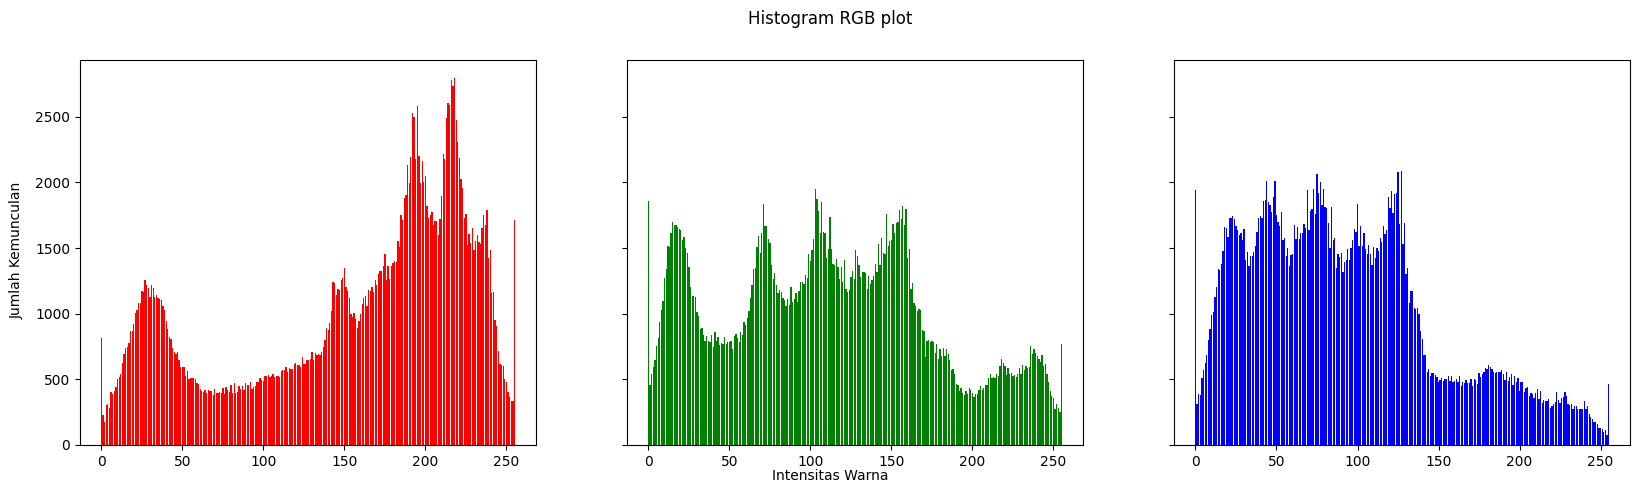

In [ ]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

# PERTANYAAN PRAKTIKUM D1

1. Buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh
NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?


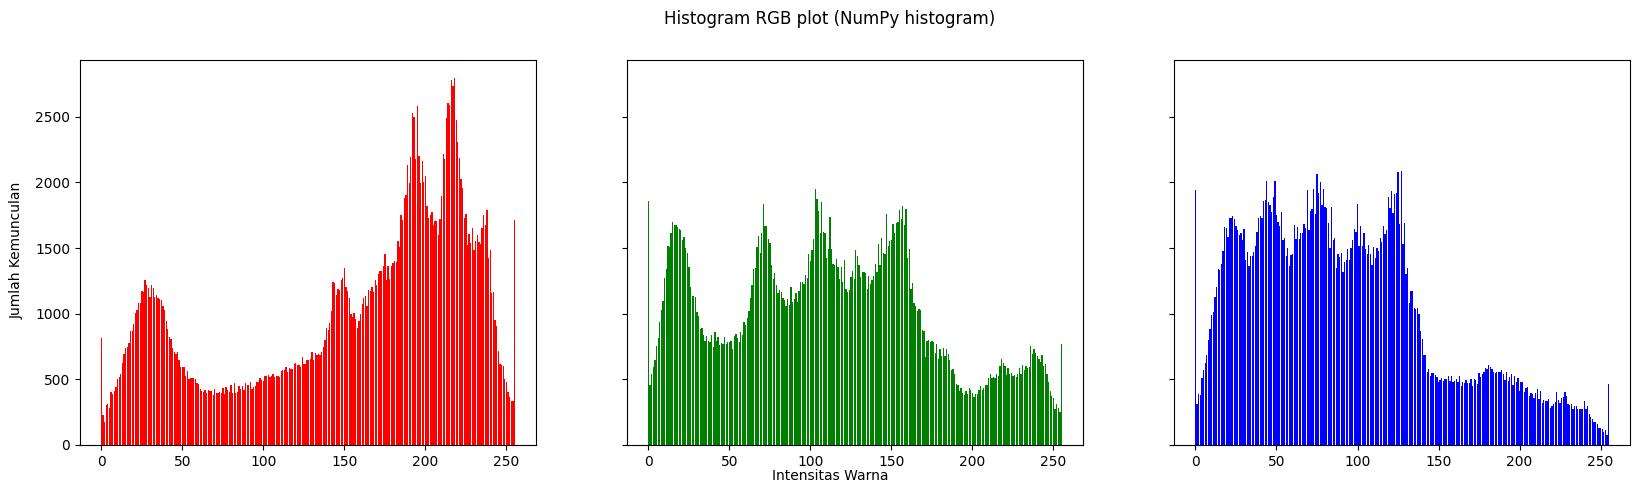

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca dan konversi citra
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel warna
r = img[:,:,0].flatten()   # flatten supaya jadi array 1D
g = img[:,:,1].flatten()
b = img[:,:,2].flatten()

# Hitung histogram dengan numpy
hist_r, bins_r = np.histogram(r, bins=256, range=(0,256))
hist_g, bins_g = np.histogram(g, bins=256, range=(0,256))
hist_b, bins_b = np.histogram(b, bins=256, range=(0,256))

# Plot hasil
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot (NumPy histogram)')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')

axs[0].bar(names, hist_r, color='red')
axs[1].bar(names, hist_g, color='green')
axs[2].bar(names, hist_b, color='blue')

plt.show()


Perbandingan hasil

1. Output histogram manual vs NumPy histogram akan sama secara bentuk (pola distribusi intensitas warna identik).

2. Perbedaannya hanya pada:

*   np.histogram() lebih efisien dan cepat karena sudah dioptimasi.
*   Kode manual memberi gambaran jelas tentang cara kerja histogram (looping, counting).

3. Kalau dicoba, grafik keduanya akan identik, kecuali ada sedikit perbedaan karena rounding/penentuan bin (tapi karena kita pakai bins=256, range=(0,256), hasilnya pasti sama).

2. Buatlah histogram dengan menggunakan dengan menggunakan image KTM lama.jpg.
Analisis distribusi intensitas dari histogram yang dihasilkan apakah gambar cenderung
gelap, terang, atau kontras rendah.

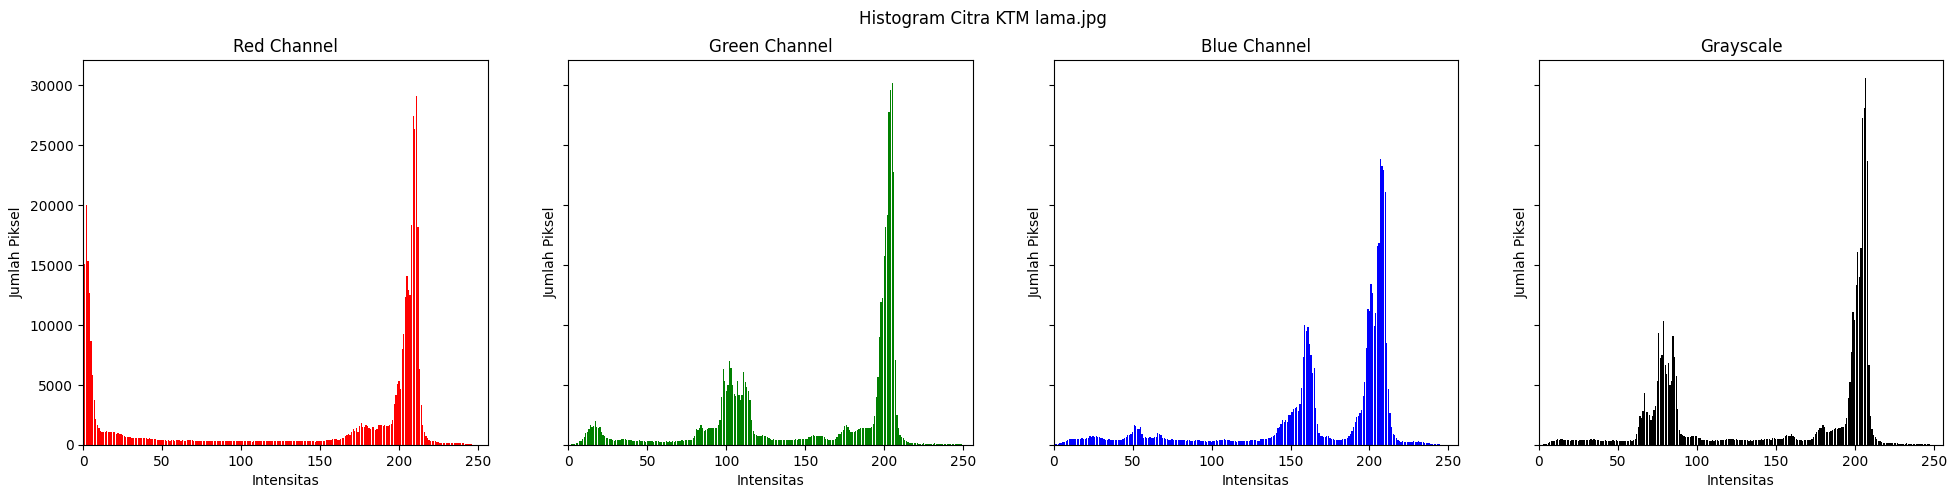

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca citra (pastikan path sesuai)
img = cv.imread('/content/drive/MyDrive/PCVK/ktm.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel warna
r = img[:,:,0].flatten()
g = img[:,:,1].flatten()
b = img[:,:,2].flatten()

# Histogram tiap channel (256 bins untuk intensitas 0–255)
hist_r, _ = np.histogram(r, bins=256, range=(0,256))
hist_g, _ = np.histogram(g, bins=256, range=(0,256))
hist_b, _ = np.histogram(b, bins=256, range=(0,256))

# Histogram grayscale untuk analisis umum
gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
hist_gray, _ = np.histogram(gray.flatten(), bins=256, range=(0,256))

# Plot RGB
fig, axs = plt.subplots(1, 4, figsize=(24,5), sharex=True, sharey=True)
fig.suptitle('Histogram Citra KTM lama.jpg')

axs[0].bar(np.arange(256), hist_r, color='red')
axs[0].set_title("Red Channel")
axs[1].bar(np.arange(256), hist_g, color='green')
axs[1].set_title("Green Channel")
axs[2].bar(np.arange(256), hist_b, color='blue')
axs[2].set_title("Blue Channel")
axs[3].bar(np.arange(256), hist_gray, color='black')
axs[3].set_title("Grayscale")

for ax in axs:
    ax.set_xlim([0,256])
    ax.set_xlabel("Intensitas")
    ax.set_ylabel("Jumlah Piksel")

plt.show()


Analisis Distribusi Intensitas

1. Jika histogram terkonsentrasi di sebelah kiri (0–100) → citra cenderung gelap (low brightness).

2. Jika histogram banyak di kanan (150–255) → citra cenderung terang (overexposed).

3. Jika histogram terkumpul di tengah (sekitar 100–150) dan sempit → citra punya kontras rendah (terlihat kusam/pucat).

4. Jika histogram merata di seluruh rentang 0–255 → citra memiliki kontras tinggi (tajam).

## D-2 PERCOBAAN HISTOGRAM EQUALIZATION

1. Buatlah histogram citra seperti output histogram equalization dan juga tampilan
gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan
flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)

Gambar hasil equalization telah disimpan di: /content/sample_data/lena_equalized.jpg


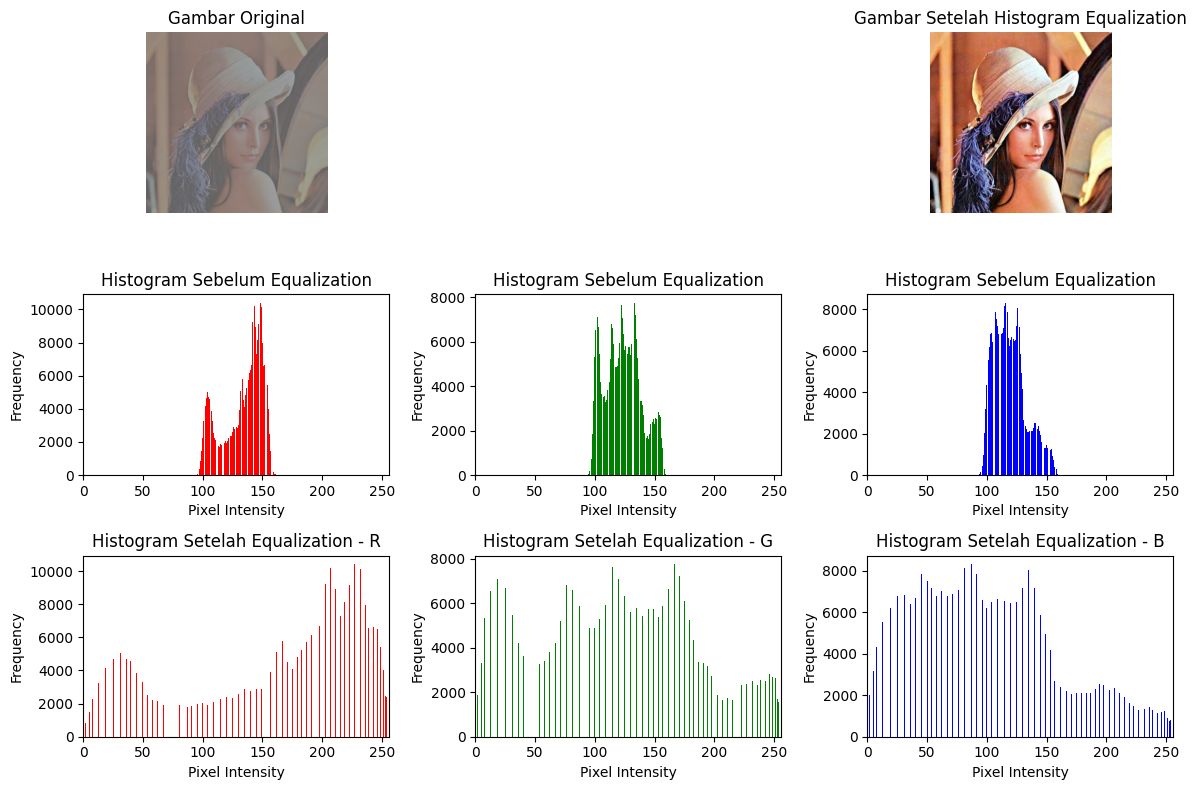

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Input image (lena_lc.jpg)
# Pastikan path file ini benar sesuai dengan lokasi di Google Drive Anda
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 2: Menghitung jumlah kemunculan setiap pixel warna (frekuensi)
hist, bins = np.histogram(img.flatten(), 256, [0, 256])

# Step 3: Menghitung penjumlahan kumulatif dari frekuensi
cdf = hist.cumsum()

# Step 4: Normalisasi, membagi dengan jumlah total pixel
cdf_normalized = cdf * hist.max() / cdf.max()

# Step 5: Implementasi rumus k0, Normalisasi CDF
cdf_m = np.ma.masked_equal(cdf, 0)  # Mengabaikan nilai 0
cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())  # Rumus Normalisasi
cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')  # Mengisi kembali nilai yang diabaikan

# Step 6: Menerapkan CDF hasil equalization pada gambar
img_equalized = cdf_final[img]

# --- PENAMBAHAN KODE UNTUK MENYIMPAN GAMBAR ---
# Konversi kembali gambar dari RGB ke BGR sebelum menyimpan dengan cv2
img_equalized_bgr = cv2.cvtColor(img_equalized, cv2.COLOR_RGB2BGR)
# Simpan gambar ke folder /content/sample_data/
output_path = '/content/sample_data/lena_equalized.jpg'
cv2.imwrite(output_path, img_equalized_bgr)
print(f"Gambar hasil equalization telah disimpan di: {output_path}")
# ---------------------------------------------


# --- KODE PLOTTING (TIDAK BERUBAH) ---
plt.figure(figsize=(12, 8))

plt.subplot(3, 3, 1)
plt.imshow(img)
plt.title('Gambar Original')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(img_equalized)
plt.title('Gambar Setelah Histogram Equalization')
plt.axis('off')

colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    plt.subplot(3, 3, 3 + i + 1)
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.bar(range(256), hist.flatten(), color=color)
    plt.title('Histogram Sebelum Equalization')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

for i, color in enumerate(colors):
    plt.subplot(3, 3, 6 + i + 1)
    hist_eq = cv2.calcHist([img_equalized], [i], None, [256], [0, 256])
    # Mengubah plot menjadi bar agar konsisten
    plt.bar(range(256), hist_eq.flatten(), color=color)
    plt.title(f'Histogram Setelah Equalization - {color.upper()}')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

2. Setelah mengerjakan langkah no. 1, buatlah histogram citra yang sama akan tetapi
menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist” seperti pada
potongan kode berikut ini.

Gambar hasil equalization (metode CV2) telah disimpan di: /content/sample_data/lena_equalized_cv2.jpg


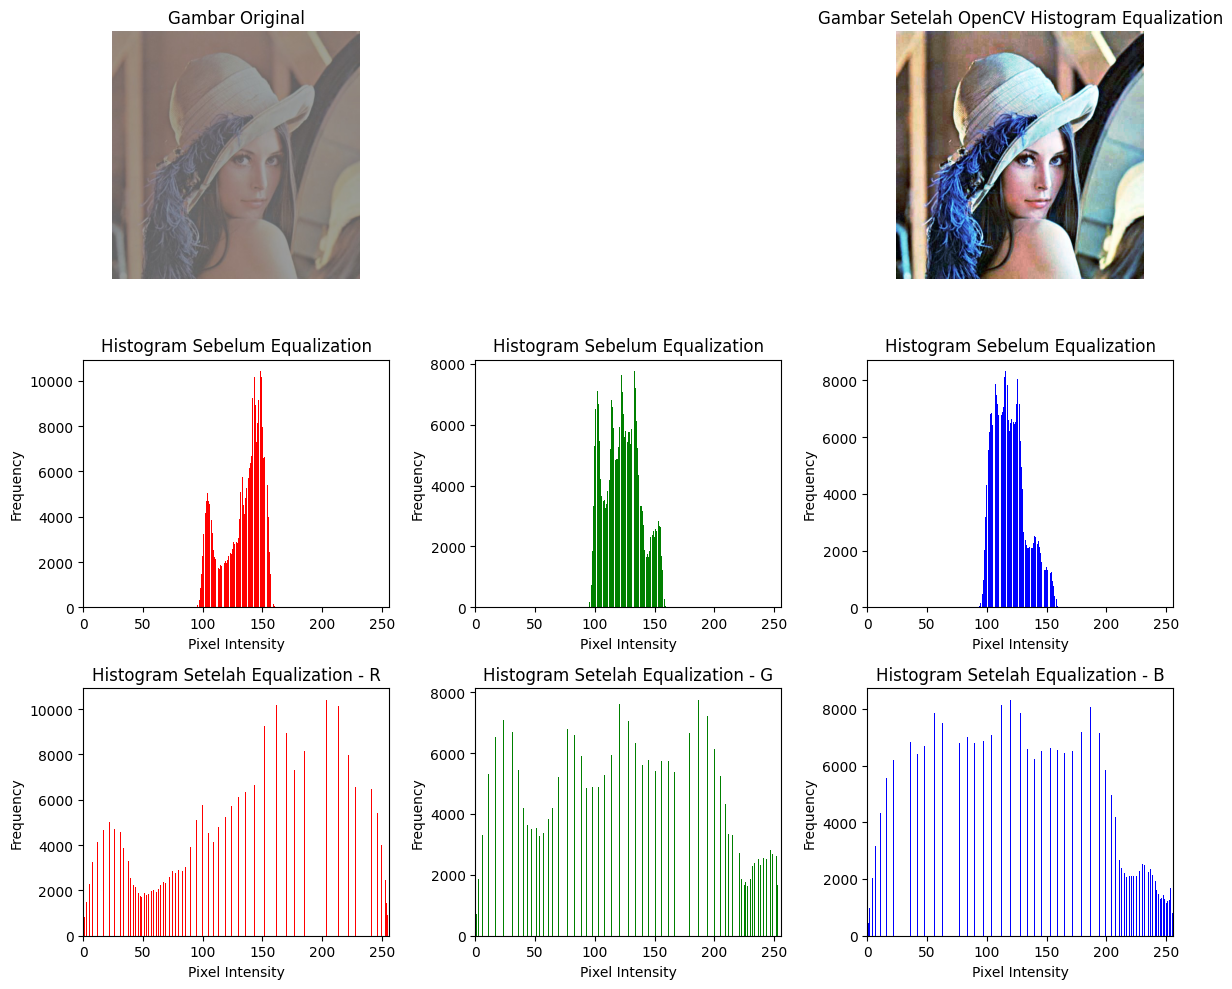

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Input image (lena_lc.jpg)
# Pastikan path file ini benar
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/lena_lc.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 3: Histogram equalization using cv2.equalizeHist
img_equalized = np.zeros_like(img)
for i in range(3):
    img_equalized[:, :, i] = cv2.equalizeHist(img[:, :, i])

# --- PENAMBAHAN KODE UNTUK MENYIMPAN GAMBAR ---
# Konversi kembali gambar dari RGB ke BGR sebelum menyimpan dengan cv2
img_equalized_bgr = cv2.cvtColor(img_equalized, cv2.COLOR_RGB2BGR)
# Simpan gambar ke folder /content/sample_data/
output_path = '/content/sample_data/lena_equalized_cv2.jpg'
cv2.imwrite(output_path, img_equalized_bgr)
print(f"Gambar hasil equalization (metode CV2) telah disimpan di: {output_path}")
# ---------------------------------------------

# Step 4: Menampilkan gambar asli dan gambar setelah equalization
plt.figure(figsize=(12, 10))

# Original Image
plt.subplot(3, 3, 1)
plt.imshow(img)
plt.title('Gambar Original')
plt.axis('off')

# OpenCV Histogram Equalized Image
plt.subplot(3, 3, 3)
plt.imshow(img_equalized)
plt.title('Gambar Setelah OpenCV Histogram Equalization')
plt.axis('off')

colors = ('r', 'g', 'b')
for i, color in enumerate(colors):
    plt.subplot(3, 3, 3 + i + 1)
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.bar(range(256), hist.flatten(), color=color)
    plt.title('Histogram Sebelum Equalization')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

for i, color in enumerate(colors):
    plt.subplot(3, 3, 6 + i + 1)
    hist_eq = cv2.calcHist([img_equalized], [i], None, [256], [0, 256])
    # Mengubah plot menjadi bar agar konsisten
    plt.bar(range(256), hist_eq.flatten(), color=color)
    plt.title(f'Histogram Setelah Equalization - {color.upper()}')
    plt.xlim([0, 256])
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

*   Hasil manual (CDF) dan hasil cv2.equalizeHist() akan sama, karena algoritma dasarnya identik.
*   Histogram sebelum cenderung menumpuk di tengah → gambar terlihat kontras rendah / agak gelap.
*   Histogram sesudah menyebar lebih merata di rentang 0–255 → gambar jadi lebih kontras dan detail lebih jelas.










# PERTANYAAN PRAKTIKUM D2

1. Perbandingan Citra Lena

    a. Gunakan hasil histogram equalization pada citra lena.jpg.

    b. Hitung nilai PSNR antara citra asli dan citra hasil equalization.

    c. Apakah nilai PSNR tinggi atau rendah? Apa arti nilai tersebut terhadap kualitas
    visual citra? Apakah ada detail baru yang muncul setelah equalization?


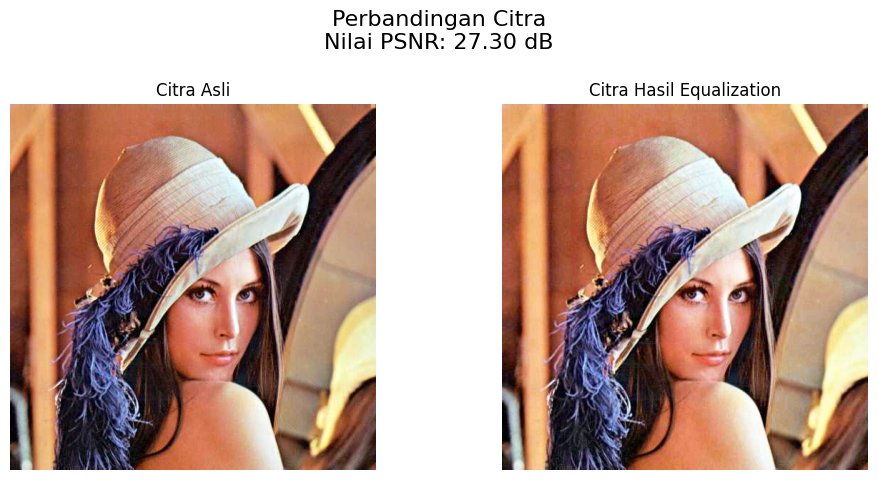

In [ ]:
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

def calculate_psnr(img1, img2):
    """Fungsi untuk menghitung PSNR antara dua gambar."""
    # Pastikan gambar memiliki dimensi yang sama
    if img1.shape != img2.shape:
        raise ValueError("Input images must have the same dimensions.")

    # Hitung Mean Squared Error (MSE)
    # Konversi ke float64 untuk menghindari overflow
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)

    # Jika MSE adalah 0, artinya gambar identik, PSNR tidak terhingga (infinity)
    if mse == 0:
        return float('inf')

    # Nilai piksel maksimum (untuk gambar 8-bit adalah 255)
    max_pixel = 255.0

    # Rumus PSNR
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))

    return psnr

# --- Main script ---
# Path ke citra asli dan citra hasil equalization
path_original = '/content/drive/MyDrive/PCVK/Images/lena.jpg'
path_equalized = '/content/sample_data/lena_equalized.jpg'

# Baca kedua citra
original_image = cv2.imread(path_original)
equalized_image = cv2.imread(path_equalized)

# Pastikan kedua citra berhasil dimuat
if original_image is None:
    print(f"Error: Tidak dapat memuat gambar dari path: {path_original}")
elif equalized_image is None:
    print(f"Error: Tidak dapat memuat gambar dari path: {path_equalized}")
else:
    # Hitung PSNR
    psnr_value = calculate_psnr(original_image, equalized_image)

    # --- Membuat Tampilan Visual (Tabel) ---

    # Buat figure dan axes untuk 2 gambar (1 baris, 2 kolom)
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    # Konversi BGR (default OpenCV) ke RGB untuk ditampilkan dengan Matplotlib
    original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    equalized_rgb = cv2.cvtColor(equalized_image, cv2.COLOR_BGR2RGB)

    # Tampilkan gambar asli
    axs[0].imshow(original_rgb)
    axs[0].set_title('Citra Asli')
    axs[0].axis('off')  # Hilangkan sumbu x dan y

    # Tampilkan gambar hasil equalization
    axs[1].imshow(equalized_rgb)
    axs[1].set_title('Citra Hasil Equalization')
    axs[1].axis('off')  # Hilangkan sumbu x dan y

    # Buat judul utama yang berisi nilai PSNR
    if psnr_value == float('inf'):
        fig.suptitle('Perbandingan Citra\nPSNR: Tak Terhingga (Citra Identik)', fontsize=16)
    else:
        fig.suptitle(f'Perbandingan Citra\nNilai PSNR: {psnr_value:.2f} dB', fontsize=16)

    # Rapikan layout dan tampilkan plot
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show()

Nilai PSNR sebesar **27.30 dB** tergolong **relatif rendah**. Nilai ini secara kuantitatif menunjukkan bahwa terdapat **perbedaan visual yang signifikan** antara citra asli dan citra hasil *equalization*.

---

### Arti Nilai PSNR Terhadap Kualitas Visual

PSNR (Peak Signal-to-Noise Ratio) mengukur seberapa besar perbedaan atau "error" antara dua gambar. Semakin tinggi nilainya, semakin mirip kedua gambar tersebut.

* **Nilai PSNR > 30 dB** umumnya dianggap baik, menunjukkan kedua citra sangat mirip.
* **Nilai PSNR 20-30 dB** menunjukkan perbedaan yang dapat dilihat secara kasat mata, seperti pada kasus ini.

Namun, dalam konteks *histogram equalization*, nilai PSNR yang lebih rendah adalah **hal yang normal dan diharapkan**. Tujuannya bukanlah untuk membuat gambar yang identik, melainkan untuk **meningkatkan kontras** dengan mengubah distribusi nilai piksel. Jadi, nilai 27.30 dB ini justru mengonfirmasi bahwa algoritma *equalization* telah berhasil mengubah gambar secara signifikan untuk meningkatkan kontrasnya.

---

### Detail Baru Setelah Equalization

**Ya, ada detail baru yang muncul** setelah proses *equalization*, terutama pada area yang sebelumnya kurang kontras.

Perhatikan secara saksama pada bagian **bulu-bulu berwarna biru di topi Lena**.

* **Citra Asli**: Pada gambar asli, bagian bulu yang gelap terlihat menyatu dan kurang bertekstur.
* **Citra Hasil Equalization**: Setelah *equalization*, kontras pada area ini meningkat drastis. Tekstur helai-helai bulu dan gradasi warnanya menjadi **jauh lebih jelas dan terdefinisi**. Detail yang tadinya hilang dalam bayangan kini menjadi terlihat.

Singkatnya, meskipun nilai PSNR-nya rendah, proses *equalization* ini berhasil mencapai tujuannya yaitu meningkatkan kontras dan memunculkan detail visual yang sebelumnya tersembunyi.

2. Gunakan Citra KTM Lama.jpg

    a. Terapkan histogram equalization pada citra KTM lama.jpg.

    b. Tampilkan citra asli, citra hasil equalization, serta histogram keduanya
    dalam satu layout.

    c. Bandingkan citra KTM lama.jpg sebelum dan sesudah histogram equalization.
    Jelaskan perbedaan yang terlihat secara visual (misalnya pada detail wajah,
    teks, atau latar belakang). Apakah perubahan tersebut meningkatkan kualitas
    informasi dari citra atau justru membuat citra terlihat terlalu “keras”.

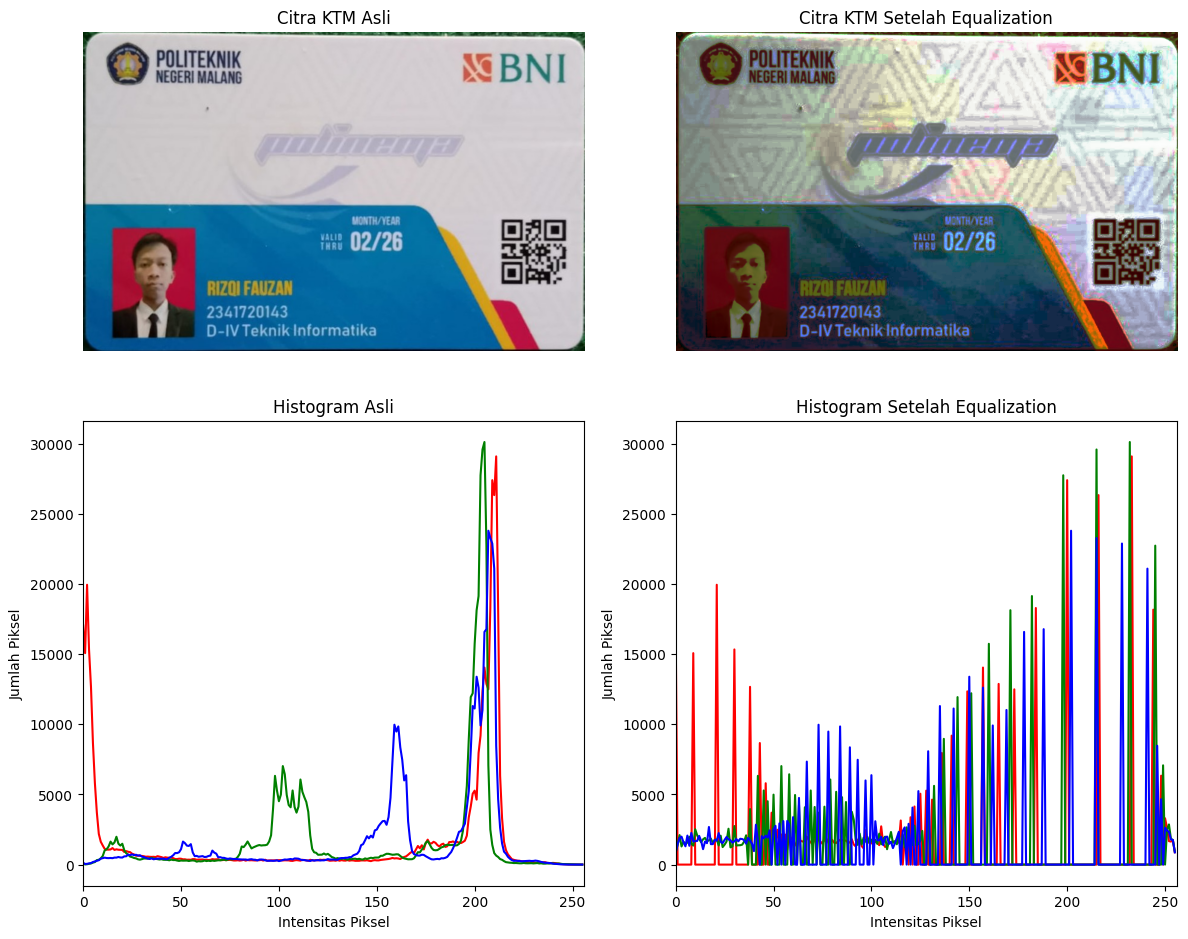

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path ke citra KTM
path_ktm = '/content/drive/MyDrive/PCVK/ktm.jpg'

# Baca gambar dalam format warna
img = cv2.imread(path_ktm)

# Pastikan gambar berhasil dimuat
if img is None:
    print(f"Error: Tidak dapat memuat gambar dari path: {path_ktm}")
    print("Pastikan path file sudah benar dan file tersebut ada di Google Drive Anda.")
else:
    # --- a. Terapkan Histogram Equalization pada Citra Warna ---

    # Konversi dari BGR (default OpenCV) ke RGB untuk pemrosesan & plotting
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Pisahkan channel R, G, B
    r, g, b = cv2.split(img_rgb)

    # Terapkan histogram equalization pada setiap channel
    r_eq = cv2.equalizeHist(r)
    g_eq = cv2.equalizeHist(g)
    b_eq = cv2.equalizeHist(b)

    # Gabungkan kembali channel yang sudah di-equalize
    equalized_img = cv2.merge((r_eq, g_eq, b_eq))

    # --- b. Tampilkan Citra dan Histogram ---

    plt.figure(figsize=(12, 10))
    colors = ('r', 'g', 'b')

    # 1. Citra Asli (Warna)
    plt.subplot(2, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Citra KTM Asli')
    plt.axis('off')

    # 2. Citra Hasil Equalization (Warna)
    plt.subplot(2, 2, 2)
    plt.imshow(equalized_img)
    plt.title('Citra KTM Setelah Equalization')
    plt.axis('off')

    # 3. Histogram Asli
    plt.subplot(2, 2, 3)
    for i, color in enumerate(colors):
        hist_original = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
        plt.plot(hist_original, color=color)
    plt.title('Histogram Asli')
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Jumlah Piksel')
    plt.xlim([0, 256])

    # 4. Histogram Hasil Equalization
    plt.subplot(2, 2, 4)
    for i, color in enumerate(colors):
        hist_equalized = cv2.calcHist([equalized_img], [i], None, [256], [0, 256])
        plt.plot(hist_equalized, color=color)
    plt.title('Histogram Setelah Equalization')
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Jumlah Piksel')
    plt.xlim([0, 256])

    plt.tight_layout()
    plt.show()

### 1. **Perbedaan Visual**

* **Wajah**:

  * Pada citra asli, wajah terlihat lebih natural dengan warna kulit yang wajar, tetapi agak gelap di beberapa area.
  * Setelah equalization, wajah terlihat lebih kontras dan terang, namun detail alami sedikit hilang sehingga tampak lebih “keras” atau artifisial.

* **Teks**:

  * Teks pada citra asli sudah terbaca cukup jelas (nama, NIM, prodi).
  * Setelah equalization, teks menjadi lebih kontras, namun sebagian huruf tampak memiliki efek “noise” atau bercahaya berlebih sehingga menurunkan kenyamanan baca.

* **Latar Belakang**:

  * Pada citra asli, latar belakang (warna biru, logo, pola) terlihat lembut dan halus.
  * Setelah equalization, pola latar belakang lebih muncul (terekspos), tetapi warna terlihat tidak alami dan kasar.

---

### 2. **Perubahan Histogram**

* **Histogram asli** → distribusi intensitas piksel menumpuk di area tinggi (sekitar 200), sehingga citra cenderung terang dengan kontras rendah pada beberapa bagian.
* **Histogram equalized** → distribusi intensitas lebih merata di seluruh rentang (0–255). Ini meningkatkan kontras, tetapi juga menimbulkan efek “keras” pada visual.

---

### 3. **Apakah Kualitas Informasi Meningkat?**

* **Meningkat** pada:

  * Kontras citra (objek lebih jelas dipisahkan).
  * Detail tertentu (misalnya pola latar belakang, kontur wajah) jadi lebih terlihat.

* **Menurun** pada:

  * Naturalitas citra (warna tidak realistis).
  * Kenyamanan visual (tampak kasar, terlalu kontras).
  * Potensi munculnya noise pada teks atau area gelap.

---

### **Kesimpulan**

Histogram equalization **meningkatkan kontras** citra KTM, membuat detail lebih menonjol. Namun, pada kasus ini hasilnya justru membuat citra terlihat terlalu “keras” dan tidak natural. Untuk kebutuhan dokumentasi resmi (seperti KTM), citra asli sebenarnya lebih nyaman dilihat. Equalization lebih cocok digunakan bila citra awal terlalu gelap atau detail penting sulit terlihat.

---

# D-3 TUGAS PRAKTIKUM DITHERING

1. Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image
awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman
modul ini! (Gunakan gambar lena.jpg)

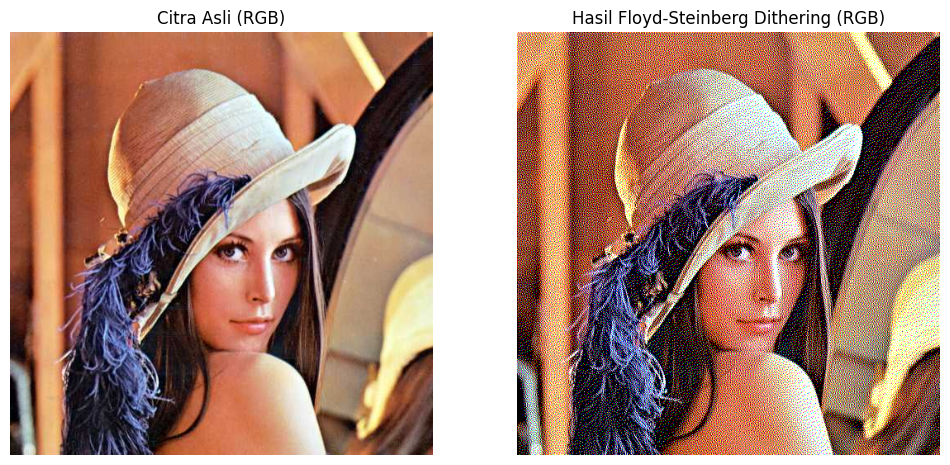

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca citra lena (berwarna)
img = cv2.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # ubah BGR ke RGB agar benar tampil di matplotlib

# Copy citra ke float untuk dithering
img_dither = img.astype(float)

# 2. Floyd-Steinberg dithering untuk tiap channel (R,G,B)
rows, cols, ch = img_dither.shape
for y in range(rows):
    for x in range(cols):
        for c in range(ch):  # channel loop
            old_pixel = img_dither[y, x, c]
            new_pixel = 255 if old_pixel > 127 else 0   # threshold biner
            img_dither[y, x, c] = new_pixel
            quant_error = old_pixel - new_pixel

            # Sebarkan error ke tetangga
            if x+1 < cols:
                img_dither[y, x+1, c] += quant_error * 7/16
            if y+1 < rows and x-1 >= 0:
                img_dither[y+1, x-1, c] += quant_error * 3/16
            if y+1 < rows:
                img_dither[y+1, x, c] += quant_error * 5/16
            if y+1 < rows and x+1 < cols:
                img_dither[y+1, x+1, c] += quant_error * 1/16

# Pastikan hasil tetap dalam 0–255
img_dither = np.clip(img_dither, 0, 255).astype(np.uint8)

# 3. Tampilkan hasil dalam satu layout
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Citra Asli (RGB)")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Hasil Floyd-Steinberg Dithering (RGB)")
plt.imshow(img_dither)
plt.axis("off")

plt.show()


2. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram
equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil
histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga
menampilkan gambar di bawah ini!

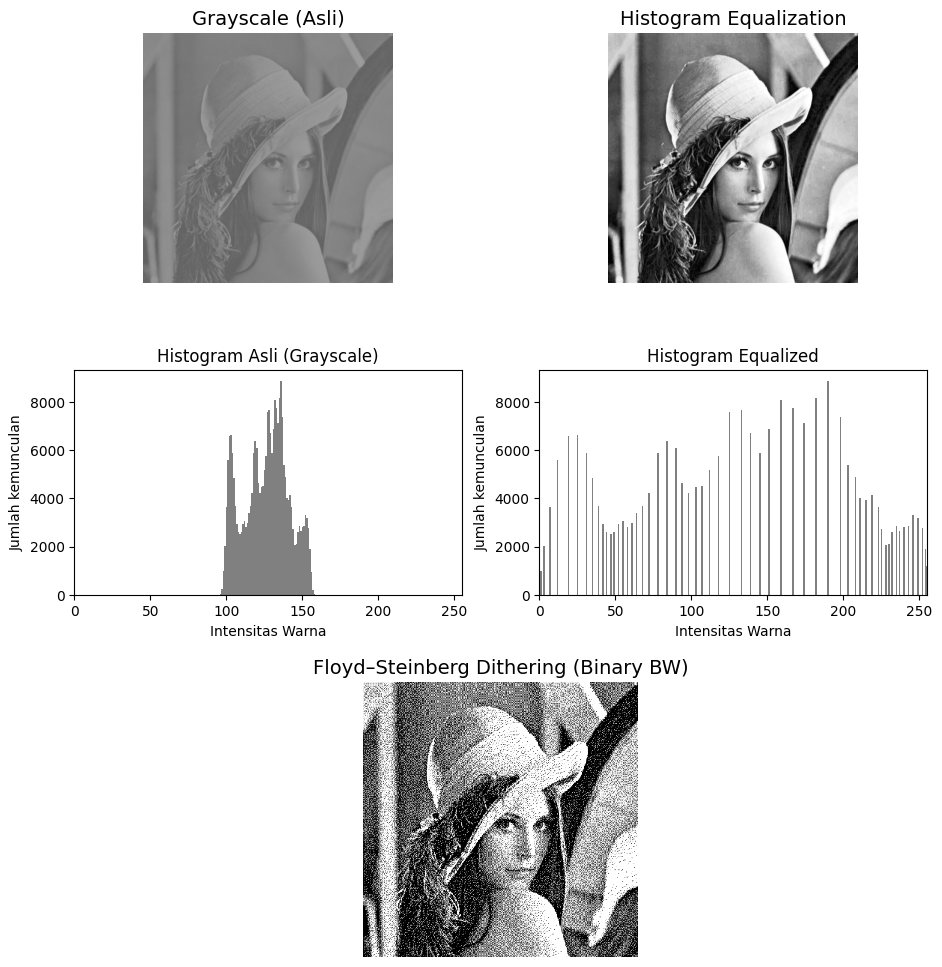

In [10]:
# --------------------------------------------------------
# Praktikum Pengolahan Citra Digital
# Histogram Equalization + Floyd–Steinberg Dithering
# Layout: 2 gambar atas | 2 histogram tengah | 1 dithering bawah
# --------------------------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Load gambar (sesuaikan path jika perlu) ---
path = '/content/drive/MyDrive/PCVK/Images/lena_lc.jpg'
img_bgr = cv2.imread(path)
if img_bgr is None:
    raise FileNotFoundError(f"File tidak ditemukan: {path}\nPastikan Drive sudah di-mount dan path benar.")
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# --- 2) Histogram Equalization ---
equalized = cv2.equalizeHist(gray)

# --- 3) Floyd–Steinberg Dithering (versi biner hitam-putih) ---
def floyd_steinberg_dithering(img):
    h, w = img.shape
    arr = img.astype(np.float32).copy()
    for y in range(h):
        for x in range(w):
            old = arr[y, x]
            new = 0 if old < 128 else 255
            arr[y, x] = new
            err = old - new
            if x + 1 < w:
                arr[y, x+1] += err * (7/16)
            if y + 1 < h:
                if x - 1 >= 0:
                    arr[y+1, x-1] += err * (3/16)
                arr[y+1, x] += err * (5/16)
                if x + 1 < w:
                    arr[y+1, x+1] += err * (1/16)
    arr = np.clip(arr, 0, 255)
    return arr.astype(np.uint8)

dithered = floyd_steinberg_dithering(equalized)

# --- 4) Hitung histogram ---
hist_gray, _ = np.histogram(gray, bins=256, range=(0,256))
hist_eq, _   = np.histogram(equalized, bins=256, range=(0,256))
bins = np.arange(256)

# --- 5) Plot layout ---
fig = plt.figure(figsize=(11,12))
gs = fig.add_gridspec(3, 2, height_ratios=[1.0, 0.9, 1.1], hspace=0.35)

# Baris 1 (gambar)
ax_img1 = fig.add_subplot(gs[0,0])
ax_img1.imshow(gray, cmap='gray', vmin=0, vmax=255)
ax_img1.set_title('Grayscale (Asli)', fontsize=14)
ax_img1.axis('off')

ax_img2 = fig.add_subplot(gs[0,1])
ax_img2.imshow(equalized, cmap='gray', vmin=0, vmax=255)
ax_img2.set_title('Histogram Equalization', fontsize=14)
ax_img2.axis('off')

# Baris 2 (histogram)
ax_h1 = fig.add_subplot(gs[1,0])
ax_h1.bar(bins, hist_gray, width=1.0, color='gray')
ax_h1.set_xlim(0,255)
ax_h1.set_title('Histogram Asli (Grayscale)', fontsize=12)
ax_h1.set_xlabel('Intensitas Warna')
ax_h1.set_ylabel('Jumlah kemunculan')

ax_h2 = fig.add_subplot(gs[1,1])
ax_h2.bar(bins, hist_eq, width=1.0, color='gray')
ax_h2.set_xlim(0,255)
ax_h2.set_title('Histogram Equalized', fontsize=12)
ax_h2.set_xlabel('Intensitas Warna')
ax_h2.set_ylabel('Jumlah kemunculan')

# Baris 3 (dithering full-width)
ax_dither = fig.add_subplot(gs[2, :])
display_h = 420
display_w = int(dithered.shape[1] * (display_h / max(1, dithered.shape[0])))
dither_show = cv2.resize(dithered, (display_w, display_h), interpolation=cv2.INTER_AREA)
ax_dither.imshow(dither_show, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
ax_dither.set_title('Floyd–Steinberg Dithering (Binary BW)', fontsize=14)
ax_dither.axis('off')

plt.show()
